# OWA risk measures

Ordered Weighted Average (OWA) risk measures describe portfolio risk as a linear
combination of **sorted portfolio returns**. The combination weights — the *OWA weights
vector* — determine which quantile of the distribution is emphasised: a vector that loads
heavily on the worst few observations gives a CVaR-like tail measure, while one that spreads
weight across the whole distribution is more like a dispersion measure.

Three things make OWA measures attractive:

  1. **Generalisation.** CVaR, Gini Mean Difference, Tail Gini, Worst Realisation, and
     Range are all special cases with closed-form weight vectors. You can define your own by
     passing any valid `w` vector to `OrderedWeightsArray`.
  2. **L-moment perspective.** A particular family of OWA weights captures the *L-moments*
     of the return distribution, giving a distribution-free risk summary that bridges
     tail quantiles and distributional spread.
  3. **Linear programming.** Every OWA measure leads to a linear programme in the portfolio
     weights, so it composes cleanly with `MeanRisk`, `RiskBudgeting`, and the rest of the
     framework without requiring a covariance matrix.

> **When to reach for this**
>
> Reach for OWA risk measures when you want a tail or dispersion measure that does not
> require a covariance matrix and that generalises beyond CVaR — especially when the
> return distribution is non-normal and you want the measure to respond to the full shape
> of the distribution rather than only to variance or a single quantile.

> **Exact vs approximate formulation**
>
> `OrderedWeightsArray` supports two internal formulations: **exact**
> (`ExactOrderedWeightsArray`), which solves a small LP per portfolio evaluation and is
> fast for a small number of assets/observations but does not scale to large problems;
> and **approximate** (`ApproxOrderedWeightsArray`, the default), which approximates the
> OWA objective with a set of p-norms and solves as a second-order cone problem, scaling
> to the normal S&P 500 slice used throughout the examples. All optimisations in this
> example use the **approximate** formulation, which is the default and is appropriate
> for the ~252 observations and ~20 assets used here.

In [1]:
using PortfolioOptimisers, PrettyTables, DataFrames

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v * 100, digits = 3)) %" : v
    end
end;

## 1. Data and shared setup

In [2]:
using CSV, TimeSeries, Clarabel

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
T = size(rd.X, 1)

slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.95),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel3, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel4, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.6,
                              "max_iter" => 1500, "tol_gap_abs" => 1e-4,
                              "tol_gap_rel" => 1e-4, "tol_ktratio" => 1e-3,
                              "tol_feas" => 1e-4, "tol_infeas_abs" => 1e-4,
                              "tol_infeas_rel" => 1e-4, "reduced_tol_gap_abs" => 1e-4,
                              "reduced_tol_gap_rel" => 1e-4, "reduced_tol_ktratio" => 1e-3,
                              "reduced_tol_feas" => 1e-4, "reduced_tol_infeas_abs" => 1e-4,
                              "reduced_tol_infeas_rel" => 1e-4),
              check_sol = (; allow_local = true, allow_almost = true))]

pr = prior(EmpiricalPrior(), rd)
opt = JuMPOptimiser(; pe = pr, slv = slv)

JuMPOptimiser
       pe ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      slv ┼ 4-element Vector{Solver}
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
          │ Solver ⋯
       wb ┼ WeightBounds
          │   lb ┼ Float64: 0.0
          │   ub ┴ Float64: 1.0
      bgt ┼ Float64: 1.0
     sbgt ┼ nothing
       lt ┼ nothing
       st ┼ nothing
     lcse ┼ nothing
      cte ┼ nothing
   gcarde ┼ nothing
  sgcarde ┼ nothing
     smtx ┼ nothing
    sgmtx ┼ nothing
      slt ┼ nothing
      sst ┼ nothing
     sglt ┼ nothing
     sgst ┼ nothing
       tn ┼ nothing
     fees ┼ n

## 2. Closed-form OWA weight vectors

The library ships functions that return the OWA weights for the classical special cases.
Each function takes `T` (the number of observations) and returns a length-`T` vector. Those
vectors are passed as `w` to `OrderedWeightsArray` to build a risk measure.

| Function | Measure | Intuition |
| -------- | ------- | --------- |
| `owa_gmd(T)` | Gini Mean Difference | Average absolute spread across all pairs; a dispersion measure |
| `owa_cvar(T)` | CVaR | Recovers the standard 5 % CVaR via the OWA framework |
| `owa_tg(T)` | Tail Gini | Gini spread over the worst tail; more sensitive to tail shape than CVaR |
| `owa_tgrg(T)` | Tail Gini Range | Tail Gini of losses minus tail Gini of gains; two-sided tail |
| `owa_wr(T)` | Worst Realisation | Equivalent to min-return; entirely determined by the single worst day |
| `owa_rg(T)` | Range | Max return minus min return; full return span |
| `owa_cvarrg(T)` | CVaR Range | CVaR of losses minus CVaR of gains |
| `owa_l_moment_crm(T)` | L-moment CRM | Higher-order L-moment convex risk measure |

In [3]:
r_gmd = OrderedWeightsArray(; w = owa_gmd(T))
r_cvar = OrderedWeightsArray(; w = owa_cvar(T))
r_tg = OrderedWeightsArray(; w = owa_tg(T))
r_tgrg = OrderedWeightsArray(; w = owa_tgrg(T))
r_wr = OrderedWeightsArray(; w = owa_wr(T))
r_rg = OrderedWeightsArray(; w = owa_rg(T))
r_cvarrg = OrderedWeightsArray(; w = owa_cvarrg(T))
r_lcrm = OrderedWeightsArray(; w = owa_l_moment_crm(T))

OrderedWeightsArray
  settings ┼ RiskMeasureSettings
           │   scale ┼ Float64: 1.0
           │      ub ┼ nothing
           │     rke ┴ Bool: true
         w ┼ 252-element Vector{Float64}
       alg ┼ ApproxOrderedWeightsArray
           │   p ┴ Vector{Float64}: [2.0, 3.0, 4.0, 10.0, 50.0]


## 3. Minimising each OWA risk measure

We build a minimum-risk `MeanRisk` portfolio for each OWA measure and collect the weights.
Because all these measures are approximated with p-norms via the default
`ApproxOrderedWeightsArray`, they all solve as second-order cone problems with Clarabel.

In [4]:
rs = [r_gmd, r_cvar, r_tg, r_tgrg, r_wr, r_rg, r_cvarrg, r_lcrm]
names_r = ["GMD", "CVaR", "TailGini", "TailGiniRange", "WorstReal", "Range", "CVaRRange",
           "L-moment"]

results = [optimise(MeanRisk(; r = r, opt = opt)) for r in rs]

pretty_table(DataFrame(hcat(rd.nx, [r.w for r in results]...),
                       [:assets; Symbol.(names_r)...]); formatters = [resfmt])

┌────────┬──────────┬──────────┬──────────┬───────────────┬───────────┬─────────
│ assets │      GMD │     CVaR │ TailGini │ TailGiniRange │ WorstReal │    Ran ⋯
│    Any │      Any │      Any │      Any │           Any │       Any │      A ⋯
├────────┼──────────┼──────────┼──────────┼───────────────┼───────────┼─────────
│   AAPL │    0.0 % │    0.0 % │    0.0 % │         0.0 % │     0.0 % │    0.0 ⋯
│    AMD │    0.0 % │    0.0 % │    0.0 % │         0.0 % │     0.0 % │    0.0 ⋯
│    BAC │    0.0 % │    0.0 % │    0.0 % │         0.0 % │     0.0 % │    0.0 ⋯
│    BBY │    0.0 % │    0.0 % │    0.0 % │         0.0 % │     0.0 % │    0.0 ⋯
│    CVX │  9.147 % │ 13.103 % │ 22.531 % │       7.412 % │  12.205 % │  7.412 ⋯
│     GE │    0.0 % │    0.0 % │    0.0 % │       0.824 % │     0.0 % │  0.824 ⋯
│     HD │    0.0 % │    0.0 % │    0.0 % │         0.0 % │     0.0 % │    0.0 ⋯
│    JNJ │ 34.514 % │ 45.411 % │  55.66 % │      36.976 % │  29.391 % │ 36.976 ⋯
│    JPM │  0.982 % │    0.0

Even though all portfolios minimise risk, the allocations differ substantially because each
measure emphasises a different aspect of the distribution:

  - **GMD** penalises pairwise spread — it concentrates into correlated low-volatility names.
  - **CVaR** focuses on the worst 5 % of days and ignores moderate losses.
  - **TailGini** also looks at the tail but responds to its *shape* (Gini spread within the
    tail), not only its level.
  - **WorstRealisation** and **Range** are extreme: the solver pushes all weight into
    whatever reduces a single day or the full span.
  - **L-moment CRM** distributes attention over many higher-order distributional moments at
    once.

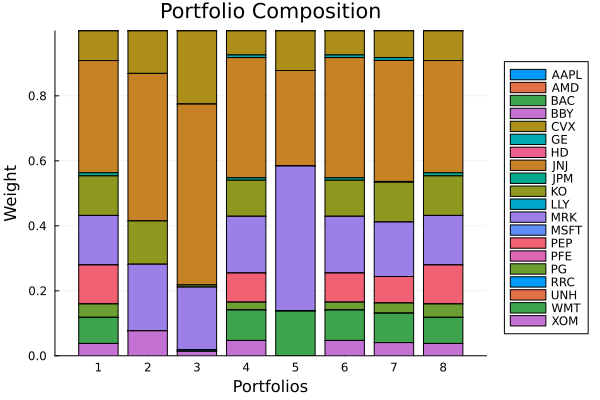

In [5]:
using StatsPlots, GraphRecipes
plot_stacked_bar_composition(results, rd)

## 4. Default approximate formulation

`OrderedWeightsArray` with no `w` and no explicit `alg` defaults to
`ApproxOrderedWeightsArray`, which approximates the OWA sort with a set of p-norms
(`p = [2, 3, 4, 10, 50]`). The resulting optimisation is a second-order cone programme.

This is the recommended path when you do not need an exact closed-form weight vector and
want the solver to use the most tractable formulation.

In [6]:
r_approx = OrderedWeightsArray()
res_approx = optimise(MeanRisk(; r = r_approx, opt = opt))
println("Approx OWA, max weight: $(round(maximum(res_approx.w)*100; digits=2)) %")

Approx OWA, max weight: 34.51 %


## 5. OWA risk measure range — two-sided tail control

`OrderedWeightsArrayRange` defines a *range* measure as the difference of two OWA
weight vectors — one for losses, one for gains. This is the OWA generalisation of a
two-sided risk measure.

The default range is `owa_tg` (lower tail) minus the reversed `owa_tg` (upper tail), which
is equivalent to `owa_tgrg`. Passing custom `w1` and `w2` gives full control over what
"bad" and "good" outcomes each side of the range tracks.

In [7]:
# Default range: tail Gini losses vs tail Gini gains.
r_range_default = OrderedWeightsArrayRange()

# Custom range: CVaR losses vs worst realisation gains.
T_obs = T
r_range_custom = OrderedWeightsArrayRange(; w1 = owa_cvar(T_obs),
                                          w2 = reverse(owa_wr(T_obs)))

res_range_d = optimise(MeanRisk(; r = r_range_default, opt = opt))
res_range_c = optimise(MeanRisk(; r = r_range_custom, opt = opt))

pretty_table(DataFrame(; :assets => rd.nx, :TailGiniRange => res_range_d.w,
                       :CVaR_vs_WorstGain => res_range_c.w); formatters = [resfmt])

┌────────┬───────────────┬───────────────────┐
│ assets │ TailGiniRange │ CVaR_vs_WorstGain │
│ String │       Float64 │           Float64 │
├────────┼───────────────┼───────────────────┤
│   AAPL │         0.0 % │             0.0 % │
│    AMD │         0.0 % │             0.0 % │
│    BAC │         0.0 % │             0.0 % │
│    BBY │         0.0 % │             0.0 % │
│    CVX │       1.142 % │             0.0 % │
│     GE │       0.135 % │           5.791 % │
│     HD │       3.307 % │           9.397 % │
│    JNJ │       51.25 % │           0.902 % │
│    JPM │         0.0 % │           2.378 % │
│     KO │       7.633 % │             0.0 % │
│    LLY │         0.0 % │           6.782 % │
│    MRK │      18.154 % │           24.54 % │
│   MSFT │         0.0 % │             0.0 % │
│    PEP │         0.0 % │          25.725 % │
│    PFE │         0.0 % │             0.0 % │
│      ⋮ │             ⋮ │                 ⋮ │
└────────┴───────────────┴───────────────────┘
             

## 6. Maximum Sharpe ratio with an OWA measure

OWA risk measures work as the denominator in a risk-adjusted ratio objective too, which lets
you find the portfolio that maximises return per unit of tail dispersion rather than return
per unit of variance.

In [8]:
rf = 4.2 / 100 / 252
res_ratio = optimise(MeanRisk(; r = r_gmd, obj = MaximumRatio(; rf = rf), opt = opt))
println("GMD Sharpe portfolio, max weight: $(round(maximum(res_ratio.w)*100; digits=2)) %")
pretty_table(DataFrame(; :assets => rd.nx, :weight => res_ratio.w); formatters = [resfmt])

GMD Sharpe portfolio, max weight: 66.84 %
┌────────┬──────────┐
│ assets │   weight │
│ String │  Float64 │
├────────┼──────────┤
│   AAPL │    0.0 % │
│    AMD │   -0.0 % │
│    BAC │    0.0 % │
│    BBY │    0.0 % │
│    CVX │    0.0 % │
│     GE │    0.0 % │
│     HD │    0.0 % │
│    JNJ │    0.0 % │
│    JPM │    0.0 % │
│     KO │    0.0 % │
│    LLY │    0.0 % │
│    MRK │ 66.842 % │
│   MSFT │    0.0 % │
│    PEP │    0.0 % │
│    PFE │    0.0 % │
│      ⋮ │        ⋮ │
└────────┴──────────┘
       5 rows omitted


## 7. L-moment CRM: controlling risk aversion with `g`

The `NormalisedConstantRelativeRiskAversion` estimator generates L-moment CRM
weights parameterised by `g ∈ (0, 1)`. As `g → 0` the weights concentrate on the worst
observations; as `g → 1` they spread more evenly across the distribution.

In [9]:
gs = [0.25, 0.5, 0.75]
lcrm_results = map(gs) do g
    w_lcrm = owa_l_moment_crm(T, NormalisedConstantRelativeRiskAversion(; g = g); k = 5)
    r_lcrm_g = OrderedWeightsArray(; w = w_lcrm)
    return optimise(MeanRisk(; r = r_lcrm_g, opt = opt))
end

pretty_table(DataFrame(hcat(rd.nx, [r.w for r in lcrm_results]...),
                       [:assets, Symbol.("g=" .* string.(gs))...]); formatters = [resfmt])

┌────────┬──────────┬──────────┬──────────┐
│ assets │   g=0.25 │    g=0.5 │   g=0.75 │
│    Any │      Any │      Any │      Any │
├────────┼──────────┼──────────┼──────────┤
│   AAPL │    0.0 % │    0.0 % │    0.0 % │
│    AMD │    0.0 % │    0.0 % │    0.0 % │
│    BAC │    0.0 % │    0.0 % │    0.0 % │
│    BBY │    0.0 % │    0.0 % │    0.0 % │
│    CVX │   9.42 % │  9.829 % │ 10.116 % │
│     GE │    0.0 % │    0.0 % │    0.0 % │
│     HD │    0.0 % │    0.0 % │    0.0 % │
│    JNJ │ 38.628 % │ 40.414 % │ 42.017 % │
│    JPM │  2.583 % │  2.759 % │  2.885 % │
│     KO │ 12.796 % │  12.55 % │ 12.423 % │
│    LLY │    0.0 % │    0.0 % │    0.0 % │
│    MRK │ 16.025 % │ 15.906 % │  15.91 % │
│   MSFT │    0.0 % │    0.0 % │    0.0 % │
│    PEP │  5.156 % │  4.071 % │  2.781 % │
│    PFE │    0.0 % │    0.0 % │    0.0 % │
│      ⋮ │        ⋮ │        ⋮ │        ⋮ │
└────────┴──────────┴──────────┴──────────┘
                             5 rows omitted


Lower `g` concentrates into defensive names (the worst-day sensitivity dominates); higher
`g` spreads across more assets as the estimator starts to care about moderate returns too.

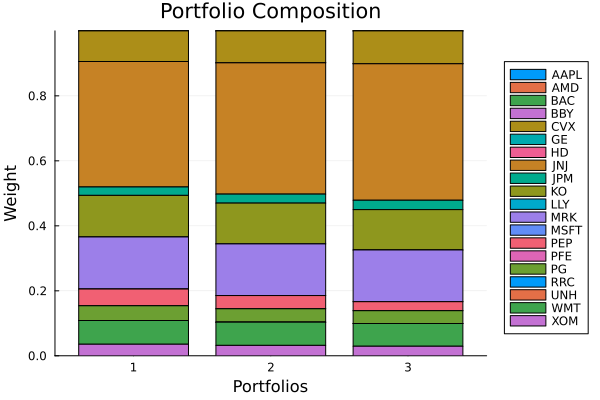

In [10]:
# The risk-aversion sweep, side by side: lower `g` (left) loads the defensive names harder.
plot_stacked_bar_composition(lcrm_results, rd)

## Summary

OWA risk measures offer a linear-programme-compatible family that spans the full
spectrum from worst-realisation to distributional dispersion:

  - **Closed-form vectors** (`owa_gmd`, `owa_tg`, `owa_cvar`, …) plug directly into
    `OrderedWeightsArray` with no solver required for weight construction.
  - **Default approximate formulation** (`ApproxOrderedWeightsArray`) scales to realistic
    universes without any code changes.
  - **L-moment CRM** with `NormalisedConstantRelativeRiskAversion` and `g` gives a
    continuously tunable risk-aversion dial.
  - **Range variants** (`OrderedWeightsArrayRange`) track two-sided tail exposure.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*